## 10 Fold Cross Validation

### Linear Interpolation

Fold 1/10...
Fold 2/10...
Fold 3/10...
Fold 4/10...
Fold 5/10...
Fold 6/10...
Fold 7/10...
Fold 8/10...
Fold 9/10...
Fold 10/10...

Cross-Validation Results:
              MSE       MAE      RMSE        R²
0        0.002969  0.042878  0.054489  0.365366
1        0.003400  0.044063  0.058312  0.379333
2        0.002755  0.041136  0.052492  0.480797
3        0.002818  0.040274  0.053089  0.350479
4        0.002911  0.040935  0.053951  0.399959
5        0.003185  0.043285  0.056434  0.365712
6        0.003448  0.044095  0.058723  0.329396
7        0.002915  0.042414  0.053986  0.434076
8        0.003608  0.046021  0.060065  0.131631
9        0.003180  0.043993  0.056393  0.328855
Average  0.003119  0.042909  0.055793  0.356560

Average Execution Time per Fold: 0.1985 seconds


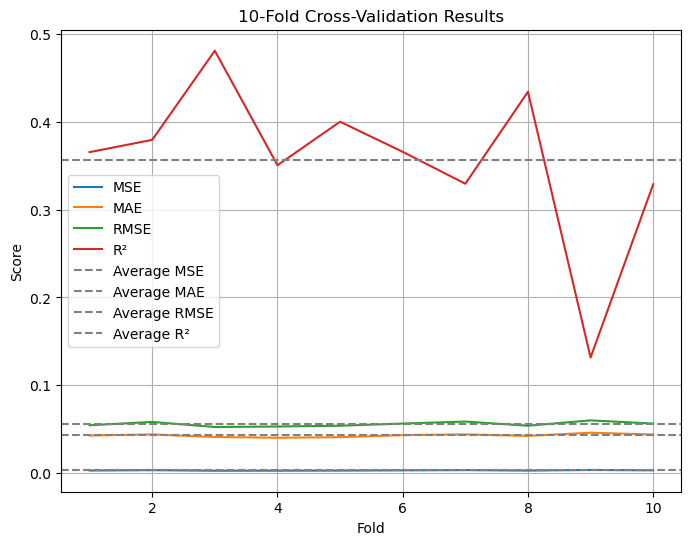

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from math import sqrt
import pandas as pd
import time

# Load the data
file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/'  # Update this path
coords = np.load(file_path + 'coords.npy')
band_powers = np.load(file_path + 'band_powers.npy', allow_pickle=True).item()

# Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Step 1: Define your interpolation function
def interpolate(coords, values, new_coords, timing=False):
    start_time = time.time()

    # Perform linear interpolation using griddata
    predicted_values = griddata(coords, values, new_coords, method='linear')

    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Step 2: Define the metric calculation function
def calculate_metrics(pred_values, test_values, metrics=None):
    scores = {}
    if 'MSE' in metrics:
        scores['MSE'] = mean_squared_error(test_values, pred_values)
    if 'MAE' in metrics:
        scores['MAE'] = mean_absolute_error(test_values, pred_values)
    if 'RMSE' in metrics:
        scores['RMSE'] = sqrt(mean_squared_error(test_values, pred_values))
    if 'R²' in metrics:
        scores['R²'] = r2_score(test_values, pred_values)
    
    return scores

# Step 3: Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialise arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
metric_results = np.zeros((num_folds, len(metrics)))
timings = np.zeros((num_folds))

# Step 4: Perform 10-fold cross-validation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    print(f"Fold {i + 1}/{num_folds}...")

    # Split into training and testing sets
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]

    # Run interpolation and measure execution time
    pred_values, timings[i] = interpolate(train_coords, train_values, test_coords, timing=True)

    # Remove NaN values (in case of failed interpolation points)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]

    # Compute evaluation metrics
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values, metrics)
        metric_results[i] = [scores[m] for m in metrics]
    else:
        print(f"⚠️ Warning: No valid predictions in fold {i + 1}")

# Step 5: Average results across all folds
avg_metrics = metric_results.mean(axis=0)
avg_timing = timings.mean()

# Step 6: Display Results
df_results = pd.DataFrame(metric_results, columns=metrics)
df_results.loc['Average'] = avg_metrics
print("\nCross-Validation Results:")
print(df_results)

print(f"\nAverage Execution Time per Fold: {avg_timing:.4f} seconds")

# Step 7: Plot results
plt.figure(figsize=(8, 6))
for i, metric in enumerate(metrics):
    plt.plot(range(1, num_folds + 1), metric_results[:, i], label=metric)

plt.axhline(avg_metrics[0], color='gray', linestyle='--', label='Average MSE')
plt.axhline(avg_metrics[1], color='gray', linestyle='--', label='Average MAE')
plt.axhline(avg_metrics[2], color='gray', linestyle='--', label='Average RMSE')
plt.axhline(avg_metrics[3], color='gray', linestyle='--', label='Average R²')

plt.title('10-Fold Cross-Validation Results')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()


### KNN Interpolation

Fold 1/10...
Fold 2/10...
Fold 3/10...
Fold 4/10...
Fold 5/10...
Fold 6/10...
Fold 7/10...
Fold 8/10...
Fold 9/10...
Fold 10/10...

Cross-Validation Results (KNN):
              MSE       MAE      RMSE        R²
0        0.003034  0.045400  0.055078  0.352131
1        0.003152  0.044311  0.056142  0.408019
2        0.003019  0.043653  0.054942  0.432176
3        0.002619  0.041652  0.051172  0.377600
4        0.003070  0.042323  0.055409  0.351064
5        0.003012  0.044580  0.054886  0.383270
6        0.002796  0.040873  0.052873  0.449816
7        0.002757  0.041821  0.052510  0.461322
8        0.003690  0.045789  0.060748  0.065373
9        0.003422  0.045099  0.058500  0.269072
Average  0.003057  0.043550  0.055226  0.354984

Average Execution Time per Fold: 0.0008 seconds


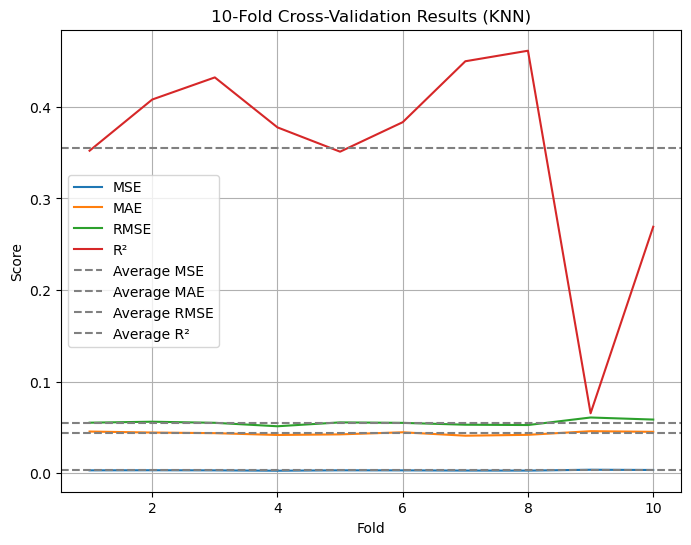

In [13]:
# Step 1: Load the data
file_path = '/Users/inayahkhan/Desktop/Group_Diss_Code/' # Update this path
coords = np.load(file_path + 'coords.npy')
band_powers = np.load(file_path + 'band_powers.npy', allow_pickle=True).item()

# Step 2: Choose which frequency band to evaluate
band = 'Delta'
values = np.array(band_powers[band])

# Step 3: Define KNN interpolation function
def knn_interpolate(coords, values, new_coords, timing=False):
    start_time = time.time()

    # Initialize KNN Regressor (5 neighbors, distance weighting)
    knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
    knn.fit(coords, values)

    # Predict interpolated values
    predicted_values = knn.predict(new_coords)

    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

# Step 4: Define the metric calculation function
def calculate_metrics(pred_values, test_values, metrics=None):
    scores = {}
    if 'MSE' in metrics:
        scores['MSE'] = mean_squared_error(test_values, pred_values)
    if 'MAE' in metrics:
        scores['MAE'] = mean_absolute_error(test_values, pred_values)
    if 'RMSE' in metrics:
        scores['RMSE'] = sqrt(mean_squared_error(test_values, pred_values))
    if 'R²' in metrics:
        scores['R²'] = r2_score(test_values, pred_values)
    
    return scores

# Step 5: Set up cross-validation
num_folds = 10
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize arrays to store results
metrics = ['MSE', 'MAE', 'RMSE', 'R²']
metric_results = np.zeros((num_folds, len(metrics)))
timings = np.zeros((num_folds))

# Step 6: Perform 10-fold cross-validation
for i, (train_index, test_index) in enumerate(kf.split(coords)):
    print(f"Fold {i + 1}/{num_folds}...")

    # Split into training and testing sets
    train_coords, test_coords = coords[train_index], coords[test_index]
    train_values, test_values = values[train_index], values[test_index]

    # Run interpolation and measure execution time
    pred_values, timings[i] = knn_interpolate(train_coords, train_values, test_coords, timing=True)

    # Remove NaN values (in case of failed interpolation points)
    valid_indices = ~np.isnan(pred_values)
    pred_values = pred_values[valid_indices]
    test_values = test_values[valid_indices]

    # Compute evaluation metrics
    if len(pred_values) > 0:
        scores = calculate_metrics(pred_values, test_values, metrics)
        metric_results[i] = [scores[m] for m in metrics]
    else:
        print(f"⚠️ Warning: No valid predictions in fold {i + 1}")

# Step 7: Average results across all folds
avg_metrics = metric_results.mean(axis=0)
avg_timing = timings.mean()

# Step 8: Display Results
df_results = pd.DataFrame(metric_results, columns=metrics)
df_results.loc['Average'] = avg_metrics
print("\nCross-Validation Results (KNN):")
print(df_results)

print(f"\nAverage Execution Time per Fold: {avg_timing:.4f} seconds")

# Step 9: Plot results
plt.figure(figsize=(8, 6))
for i, metric in enumerate(metrics):
    plt.plot(range(1, num_folds + 1), metric_results[:, i], label=metric)

plt.axhline(avg_metrics[0], color='gray', linestyle='--', label='Average MSE')
plt.axhline(avg_metrics[1], color='gray', linestyle='--', label='Average MAE')
plt.axhline(avg_metrics[2], color='gray', linestyle='--', label='Average RMSE')
plt.axhline(avg_metrics[3], color='gray', linestyle='--', label='Average R²')

plt.title('10-Fold Cross-Validation Results (KNN)')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()


KNN has more stable R2 